In [1]:
import os
import json 
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, fbeta_score, accuracy_score, recall_score

In [2]:
DATA_DIR = os.path.join("..", "data", "processed", "splits")
RESULTS_DIR = os.path.join("..", "data", "processed", "results")
MODELS_DIR = os.path.join("..", "models")
X_test_tree = pd.read_csv(os.path.join(DATA_DIR, "X_test_tree.csv"))
X_test_lr = pd.read_csv(os.path.join(DATA_DIR, "X_test_lr.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv"))

with open(os.path.join(RESULTS_DIR, "dr_results.json"), "r") as f:
    dr = json.load(f)
with open(os.path.join(RESULTS_DIR, "rf_results.json"), "r") as f:
    rf = json.load(f)
with open(os.path.join(RESULTS_DIR, "xgb_results.json"), "r") as f:
    xgb = json.load(f)
with open(os.path.join(RESULTS_DIR, "lr_results.json"), "r") as f:
    lr = json.load(f)

best_rf = joblib.load(os.path.join(MODELS_DIR, "random_forest.pkl"))
best_xgb = joblib.load(os.path.join(MODELS_DIR, "xgboost.pkl"))
best_lr = joblib.load(os.path.join(MODELS_DIR, "logistic_regression.pkl"))

In [3]:
results = pd.DataFrame([
    {'Model': 'LR on PCA', **dr['lr_pca']},
    {'Model': 'LR on LDA', **dr['lr_lda']},
    {'Model': 'Random Forest', **rf['tuned_rf']},
    {'Model': 'XGBoost', **xgb['tuned_xgb']},
    {'Model': 'Logistic Regression', **lr['tuned_lr']}
]).set_index('Model')

results.sort_values('roc_auc', ascending=False).style.highlight_max(props='color: black; background-color: lightgreen')

,accuracy,roc_auc,f2_score
Model,,,
Logistic Regression,0.824176,0.915176,0.871287
LR on LDA,0.818681,0.898381,0.843373
Random Forest,0.829670,0.897651,0.860000
XGBoost,0.807692,0.896556,0.813008
LR on PCA,0.807692,0.894974,0.833333


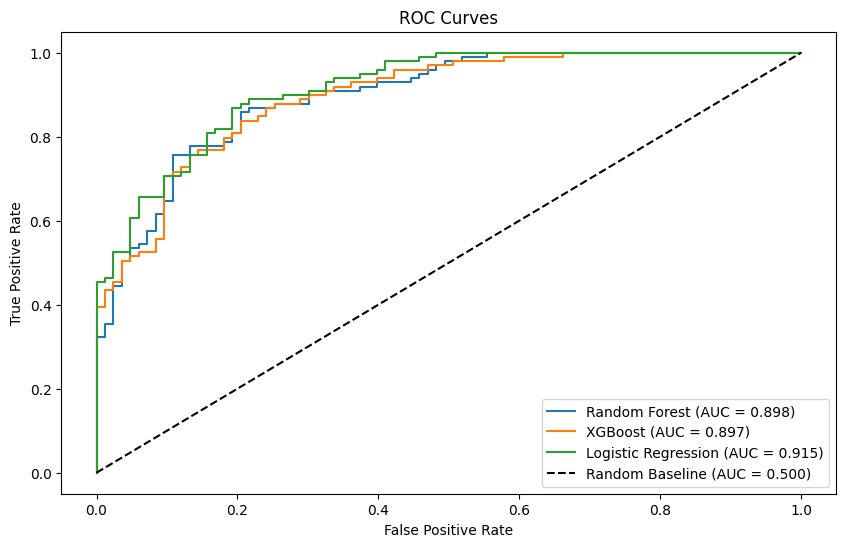

In [4]:
y_prob_rf = best_rf.predict_proba(X_test_tree)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test.squeeze(), y_prob_rf)

y_prob_xgb = best_xgb.predict_proba(X_test_tree)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test.squeeze(), y_prob_xgb)

y_prob_lr = best_lr.predict_proba(X_test_lr)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test.squeeze(), y_prob_lr)

plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

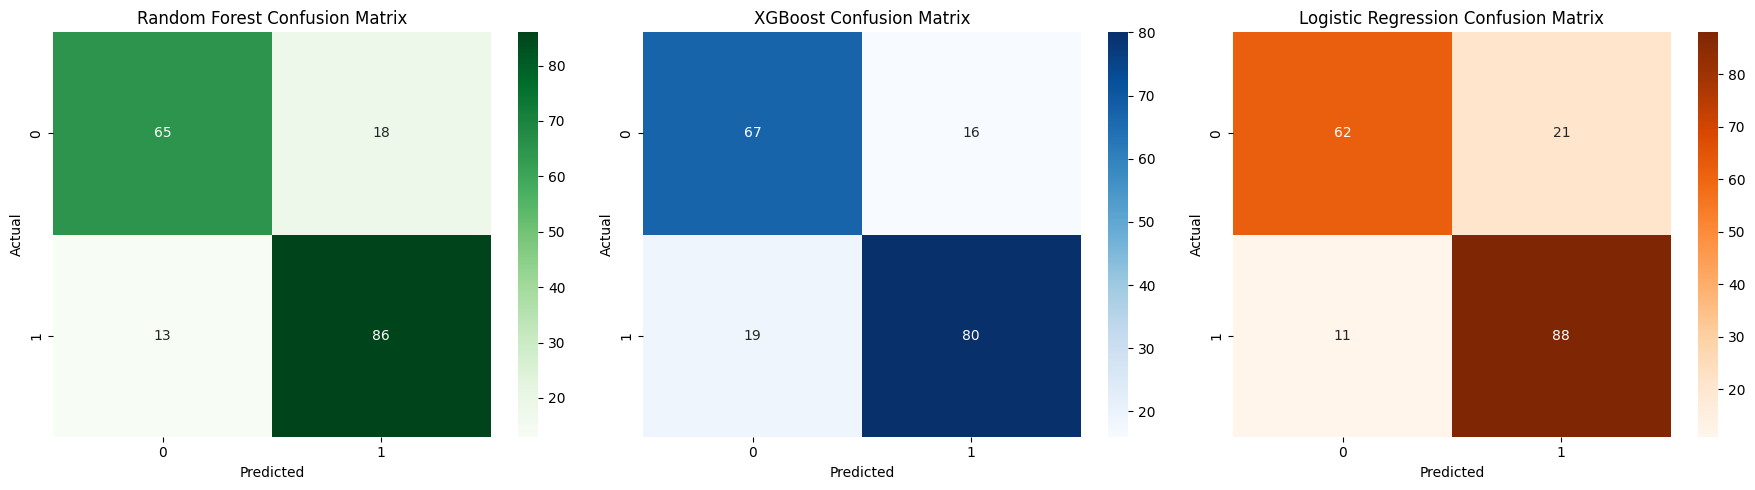

In [5]:
y_pred_rf = best_rf.predict(X_test_tree)
y_pred_xgb = best_xgb.predict(X_test_tree)
y_pred_lr = best_lr.predict(X_test_lr)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(y_test.squeeze(), y_pred_rf), annot=True, fmt='d', ax=ax[0], cmap='Greens')
ax[0].set_title('Random Forest Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')
sns.heatmap(confusion_matrix(y_test.squeeze(), y_pred_xgb), annot=True, fmt='d', ax=ax[1], cmap='Blues')
ax[1].set_title('XGBoost Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')
sns.heatmap(confusion_matrix(y_test.squeeze(), y_pred_lr), annot=True, fmt='d', ax=ax[2], cmap='Oranges')
ax[2].set_title('Logistic Regression Confusion Matrix')
ax[2].set_xlabel('Predicted')
ax[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [6]:
for name, y_pred in [
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb),
    ('Logistic Regression', y_pred_lr)
]:
    print(f"\n--- {name} ---")
    print(classification_report(y_test.squeeze(), y_pred))


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.78      0.81        83
           1       0.83      0.87      0.85        99

    accuracy                           0.83       182
   macro avg       0.83      0.83      0.83       182
weighted avg       0.83      0.83      0.83       182


--- XGBoost ---
              precision    recall  f1-score   support

           0       0.78      0.81      0.79        83
           1       0.83      0.81      0.82        99

    accuracy                           0.81       182
   macro avg       0.81      0.81      0.81       182
weighted avg       0.81      0.81      0.81       182


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.85      0.75      0.79        83
           1       0.81      0.89      0.85        99

    accuracy                           0.82       182
   macro avg       0.83      0.82      0.82       182
weigh

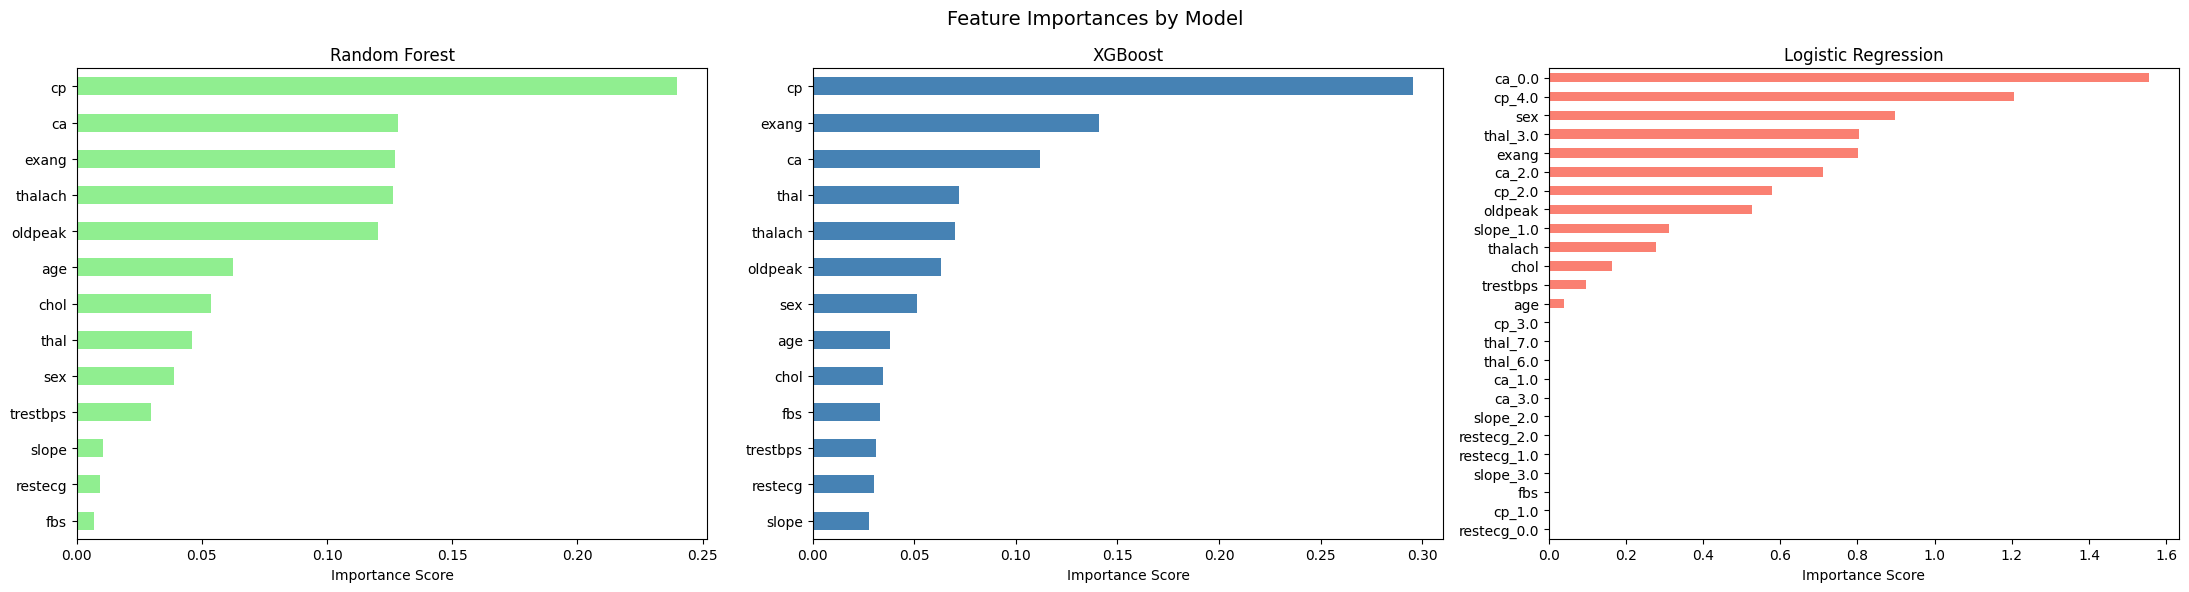

In [7]:
importances_rf = pd.Series(best_rf.feature_importances_, index=X_test_tree.columns).sort_values(ascending=False)
importances_xgb = pd.Series(best_xgb.feature_importances_, index=X_test_tree.columns).sort_values(ascending=False)
importances_lr = pd.Series(np.abs(best_lr.coef_[0]), index=X_test_lr.columns).sort_values(ascending=False)

fig, ax = plt.subplots(1, 3, figsize=(22, 6))

importances_rf.sort_values().plot(kind='barh', ax=ax[0], color='lightgreen')
ax[0].set_title('Random Forest')
ax[0].set_xlabel('Importance Score')

importances_xgb.sort_values().plot(kind='barh', ax=ax[1], color='steelblue')
ax[1].set_title('XGBoost')
ax[1].set_xlabel('Importance Score')

importances_lr.sort_values().plot(kind='barh', ax=ax[2], color='salmon')
ax[2].set_title('Logistic Regression')
ax[2].set_xlabel('Importance Score')

plt.suptitle('Feature Importances by Model', fontsize=14)
plt.tight_layout()
plt.show()

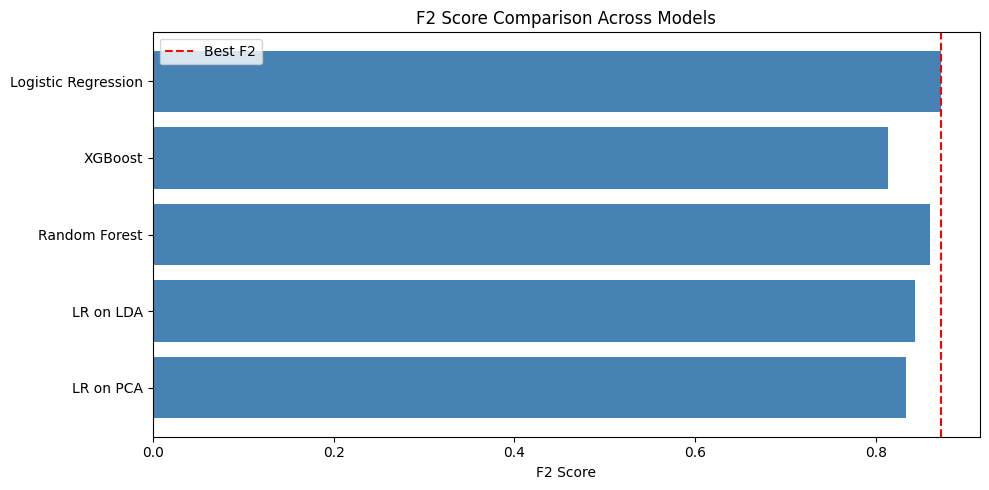

In [9]:
models = ['LR on PCA', 'LR on LDA', 'Random Forest', 'XGBoost', 'Logistic Regression']
f2_scores = [dr['lr_pca']['f2_score'], dr['lr_lda']['f2_score'], 
             rf['tuned_rf']['f2_score'], xgb['tuned_xgb']['f2_score'], lr['tuned_lr']['f2_score']]

plt.figure(figsize=(10, 5))
bars = plt.barh(models, f2_scores, color='steelblue')
plt.axvline(x=max(f2_scores), color='red', linestyle='--', label='Best F2')
plt.xlabel('F2 Score')
plt.title('F2 Score Comparison Across Models')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
models_for_threshold = [
    ('Random Forest', y_prob_rf),
    ('Logistic Regression', y_prob_lr),
    ('XGBoost', y_prob_xgb),
]

thresholds = [0.3, 0.4, 0.5, 0.6]

for model_name, y_prob in models_for_threshold:
    print(f"\n--- {model_name} ---")
    print(f"{'Threshold':<12} {'Accuracy':<12} {'Recall':<12} {'F2':<12} {'FN':<8}")
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_test.squeeze(), y_pred_t)
        fn = cm[1, 0]
        print(f"{t:<12} "
              f"{accuracy_score(y_test.squeeze(), y_pred_t):<12.4f} "
              f"{recall_score(y_test.squeeze(), y_pred_t):<12.4f} "
              f"{fbeta_score(y_test.squeeze(), y_pred_t, beta=2):<12.4f} "
              f"{fn:<8}")


--- Random Forest ---
Threshold    Accuracy     Recall       F2           FN      
0.3          0.7637       0.9596       0.8962       4       
0.4          0.8022       0.9091       0.8772       9       
0.5          0.8297       0.8687       0.8600       13      
0.6          0.8187       0.7576       0.7812       24      

--- Logistic Regression ---
Threshold    Accuracy     Recall       F2           FN      
0.3          0.8022       0.9394       0.8960       6       
0.4          0.8132       0.9091       0.8806       9       
0.5          0.8242       0.8889       0.8713       11      
0.6          0.8022       0.7677       0.7835       23      

--- XGBoost ---
Threshold    Accuracy     Recall       F2           FN      
0.3          0.7967       0.9192       0.8818       8       
0.4          0.8022       0.8788       0.8580       12      
0.5          0.8077       0.8081       0.8130       19      
0.6          0.8022       0.7677       0.7835       23      
